In [226]:
from sklearn.datasets import make_classification
import numpy as np

X, y = make_classification(n_samples=100, n_features=2, n_informative=2, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, hypercube=False, random_state=41, class_sep=20)

In [228]:
import matplotlib.pyplot as plt

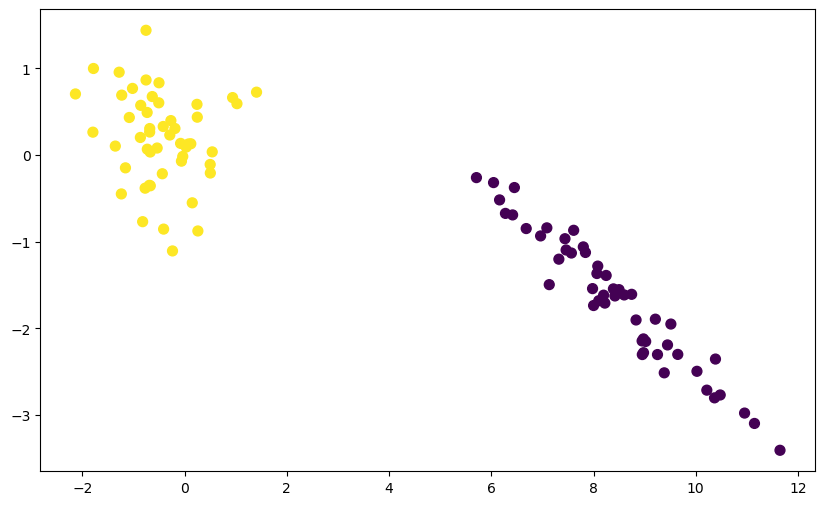

In [230]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y,  s=50)

In [232]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression(penalty=None, solver='sag')
lor.fit(X, y)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [234]:
print(lor.coef_)
print(lor.intercept_)

[[-1.58596257  0.71927634]]
[4.63154905]


In [236]:
m1 = -lor.coef_[0][0]/lor.coef_[0][1]
b1 = -lor.intercept_/lor.coef_[0][1]

In [238]:
x_input = np.linspace(-3, 3, 100)
y_input = m1*x_input + b1

In [252]:
def gd(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.2

    for i in range(5000):
        y_hat = sigmoid(np.dot(X, weights))
        weights = weights + lr * (np.dot((y - y_hat), X)) / X.shape[0]

    return weights[1:], weights[0]

In [254]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [256]:
coef_, intercept_ = gd(X, y)

In [258]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [260]:
x_input1 = np.linspace(-3, 3, 100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

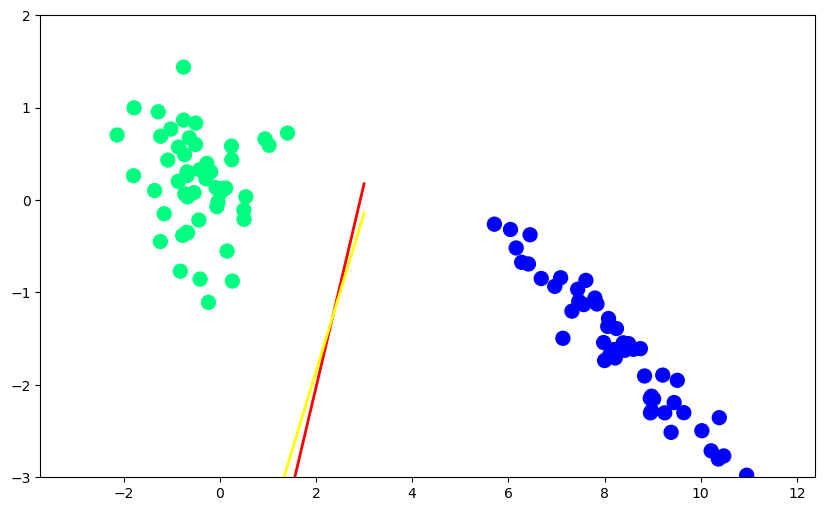

In [262]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color='red', linewidth=2)
plt.plot(x_input1, y_input1, color='yellow', linewidth=2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3, 2)